#### Early childhood, defined in this study as the period from birth to five years, is a foundational period for lifelong learning, character development and formation of healthy patterns. According to UNICEF, early childhood development (ECD) is influenced by a variety of interrelated factors, including access to early education, quality of stimulation and responsive care from adults, availability of learning materials at home, levels of supervision, and dietary diversity.


#### This report presents an analytical review of data sourced from UNICEF to examine the extent to which these variables impact the developmental outcomes of children under five. The aim is to provide evidence-based insights that can guide policy decisions, community practices, and intervention strategies for improving ECD globally, especially in low- and middle-income countries.

#### Objectives
	To analyze the correlation between attendance in early childhood education programs and developmental outcomes in children under five.
	To evaluate the role of early stimulation and responsive adult care on a child’s cognitive and emotional development.
	To examine the availability and impact of learning materials at home on early literacy and numeracy skills.
	To investigate the effects of inadequate child supervision on behavioral and developmental risks.
	To assess the relationship between dietary diversity and physical as well as cognitive development in early childhood.


In [1]:
! pip install pandas matplotlib seaborn -q


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns

In [3]:
! pip install openpyxl -q


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
b_df = pd.read_excel('SaAC-2025 Copy.xlsx', skiprows=5, sheet_name= '9. Nutrition breastfeeding and ')

In [6]:
early_df = pd.read_excel('SaAC-2025 Copy.xlsx', skiprows=5, sheet_name='10. Early Childhood Development')
early_df = early_df.iloc[1:55]

In [7]:
col_ind = [1,2] + [i for i in range(4,46,2)]

In [8]:
early_df = early_df.iloc[:,col_ind]

In [ ]:
early_df.isna().sum()

In [ ]:
for i in range(2,46):
      early_df[early_df.columns[i]].replace('-',0, inplace=True)
early_df[early_df.columns[i]].astype('float')

In [ ]:
for i in range(1,46):
    if early_df[early_df.columns[i]].dtype == 'O':
        early_df[early_df.columns[i]].replace('-',0, inplace=True)
        early_df[early_df.columns[i]].fillna(0, inplace=True)

    early_df[early_df.columns[i]].astype('float')

In [12]:
early_df.rename(columns={'Unnamed: 1':'Country'}, inplace=True)

In [13]:
early_df = early_df[early_df.columns.drop(list(early_df.filter(regex='Unnamed:')))]



## Children Developmentally on track

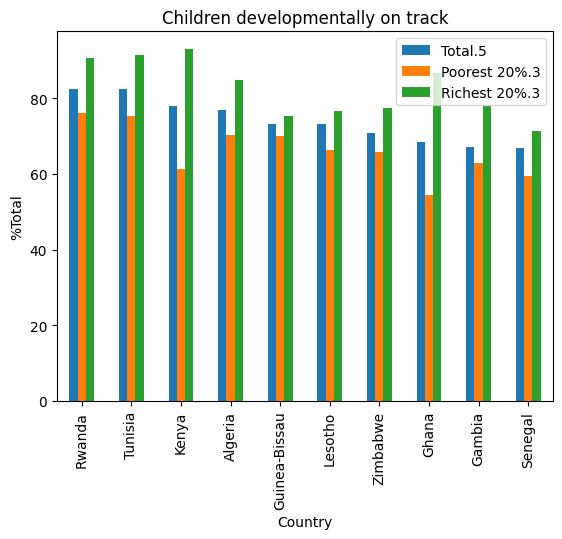

In [14]:
### Children developmentally on track
cdt_df = early_df.iloc[:55,[0,18,21,22]]
ccdt_df = cdt_df.nlargest(10,'Total.5')
ccdt_df.set_index('Country').plot(kind= 'bar', xlabel= 'Country', ylabel= '%Total', title= 'Children developmentally on track');

#### Generally, the "Richest 20%" consistently show a higher percentage of children developmentally on track compared to the "Poorest 20%" in all countries. This suggests a correlation between socioeconomic status and early childhood development.
#### This chart effectively illustrates the disparities in early childhood development outcomes (based literacy-numeracy, physical development, social-emotional development and learning as measured by the proxy ECDI definition) across different countries and, crucially, highlights the significant impact of socioeconomic inequality within those countries.
#### Rwanda and Tunisia tops the chart with the highest percentage of developmental outcomes;
#### Rwanda has invested in infrastructure, teacher training, and curriculum development, including a gender-sensitive curriculum.

#### The Tunisian Ministry of Women, Family, and Childhood (MFFE) utilized the "Systems Approach for Better Education Results" (SABER) diagnostic tools to analyze policies and programs that affect young children in Tunisia, with this SABER-ECD they collaborated with UNICEF and the World Bank, and used policy recommendations to develop strategies to improve early childhood development (ECD) for the children.
#### SABER-ECD found Tunisia’s level of ECD funding inadequate, especially in the education sector. To improve this, SABER-ECD recommended expanding and enhancing laws and regulations to provide more resources to improve early healthcare, learning, nutrition, and overall well-being of pregnant women and children.

#### The Kenyan government has focused on establishing a strong foundation for ECD through national policies and county-level implementation plans. This includes establishing ECD centers in various counties, providing guidance to pre-primary services, and offering a free ECD program in Nairobi. 
#### In 2014, the Kenyan government introduced an early childhood education programme called Tayari – a Kiswahili word that means “readiness” with the aim of enhancing readiness of children for primary school by focusing on cognitive and social skills development. This program also involves the allocation of additional resources for ECD centers.Tayari reached slightly over 72 000 pre-primary school leaners.
#### Tayari’s aim was to develop a cost-effective model of early childhood development and education that would prepare children cognitively, physically, socially and emotionally for primary school. The model had three interrelated components. The first was teacher training and classroom support. The second involved providing teachers and learners with appropriate instructional materials like learners’ work books and teacher guides. The third centred on health and hygiene knowledge, making children aware of why hand washing and healthy foods are important.
#### Kenya also conducts regular monitoring and evaluation of ECD programs to assess their effectiveness and identify areas for improvement. 

#### Guinea-Bissau has taken several steps to improve Early Childhood Care and Education (ECD) outcomes, including establishing a Preschool Inspection Directorate, developing a guide for minimum criteria for preschool operation, and partnering with organizations like UNICEF to implement programs like the Brief Early Childhood Quality Inventory (BEQI). The country is also focusing on strengthening the quality of instruction, implementing new school curriculum, and ensuring accountability for educational interventions

#### Lesotho has focused on improving ECD outcomes through several key initiatives, including expanding access to pre-primary education, strengthening the quality of preschools, and engaging families and communities in supporting young children's learning. The government prioritizes one year of pre-primary education, expands reception classes in primary schools, and increases funding for pre-primary education. Furthermore, they aim to improve the quality of preschools by reinforcing curriculum standards, teacher training, and community engagement

#### Zimbabwe has implemented several initiatives to enhance Early Childhood Development (ECD) outcomes, including mandatory ECD programs in schools, curriculum reform, teacher training, and equitable financing. These efforts aim to improve access, quality, and equity in ECD education. 



# Early Education Attendance


In [ ]:
### Attendance in early education
aed_df = early_df.iloc[:55,[0,1,4,5]]
aeed_df= aed_df.nlargest(10, 'Total')
aeed_df.set_index('Country').plot(kind='bar', xlabel= 'Country', ylabel= '%total', title= 'Access to early education');

hhaed= aed_df.merge(cdt_df, how= 'inner', on= "Country")
hhaed = hhaed.rename(columns={'Total.5':'ECD_%'})
hhaed= hhaed.drop(columns={"Poorest 20%.3","Richest 20%.3","Poorest 20%","Richest 20%"})
highaed= hhaed.nlargest(10, 'ECD_%')
highaed.set_index('Country').plot(kind= 'bar', xlabel= 'Country', ylabel= '% Total', title= 'Access to early education vs Child Development');


##### The chart above shows the percentage of children who have access to early childhood education, broken down into three categories:
	* Total  Percentage,
	* Poorest 20%,
	* Richest 20%.
##### In most countries, the richest 20% of the population have significantly higher access to early education compared to the poorest 20%.
##### Cape Verde, particularly, shows very high access to early education, indicating better early education infrastructure or programs
##### Morocco, Nigeria, and Uganda show very low access for the poorest 20%
##### Egypt shows smaller gap between the richest and poorest, suggesting more equitable access, although inequality still exist.
##### Comparing these top countries with higher access to early education to the percentage of positive delopmental outcomes in children, Ghana and Tunisia appears to have an overall higher positive outcome.
##### Ghana has an almost equal access to education to Development percentage ratio which is expecected as it is one of the few countries with a two-year preschool policy as part of its commitment to Free and Compulsory Basic Education, which places it ahead of other countries in Africa
#### Ghana has focused on increasing the availability of ECD programs, including kindergartens and preschools, particularly in underserved areas according to the Global Partnership for Education

##### The above chart highlights the inequality in access to early childhood education across countries. It suggests that economic status heavily influences a child’s likelihood of receiving early education in many African nations, highlighting a need for policy interventions to support equal access.

## Early Stimulation and Responsive Care

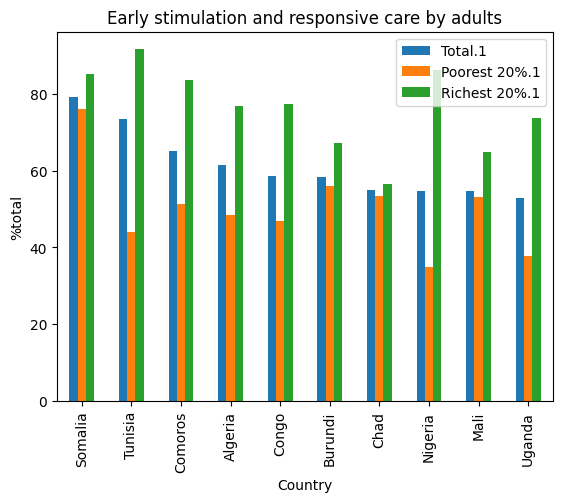

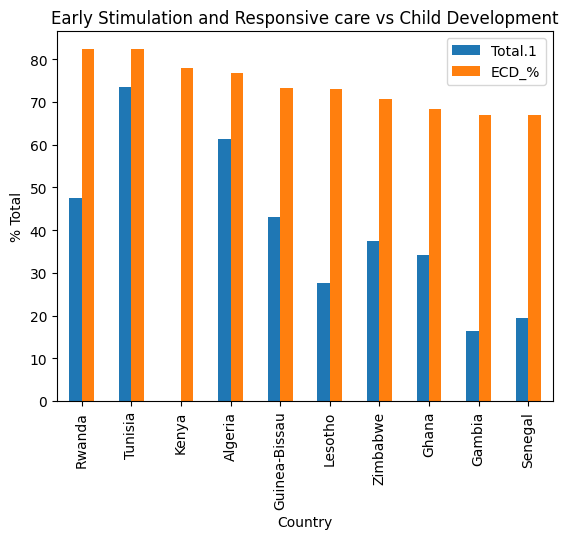

In [15]:
#### Early stimulation and responsive care by adults
esrc_df =  early_df.iloc[:55,[0,6,9,10]]
esrcc_df = esrc_df.nlargest(10,'Total.1')
esrcc_df.set_index('Country').plot(kind='bar', xlabel= 'Country', ylabel= '%total', title= 'Early stimulation and responsive care by adults');

hhesrc= esrc_df.merge(cdt_df, how= 'inner', on= "Country")
hhesrc = hhesrc.rename(columns={'Total.5':'ECD_%'})
hhesrc= hhesrc.drop(columns={"Poorest 20%.1","Richest 20%.1","Poorest 20%.3","Richest 20%.3"})
highesrc= hhesrc.nlargest(10, 'ECD_%')
highesrc.set_index('Country').plot(kind= 'bar', xlabel= 'Country', ylabel= '% Total', title= 'Early Stimulation and Responsive care vs Child Development');

#### * This chart highlights the disproportion in access to nurturing environment which is essential for child development
#### In nearly all countries, children from the richest households receive significantly more early stimulation and responsive care from adults compared to those from the poorest households.

##### in countries like Burundi, mali and Chad, while a gap exists, it is narrower when compared to the highest other countries.

#### Children from wealthier backgrounds are more likely to receive the early stimulation and responsive care necessary for optimal development. This imbalance can lead to long-term inequalities in cognitive, social, and emotional development, potentially continuing cycles of poverty and disadvantage.

## Learning Materials at Home

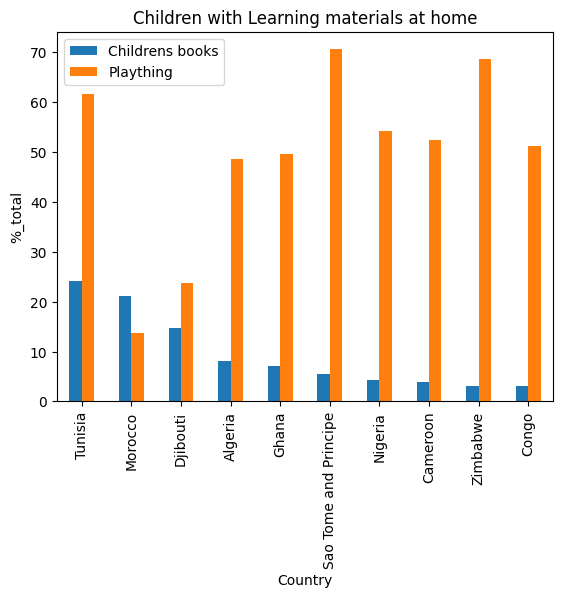

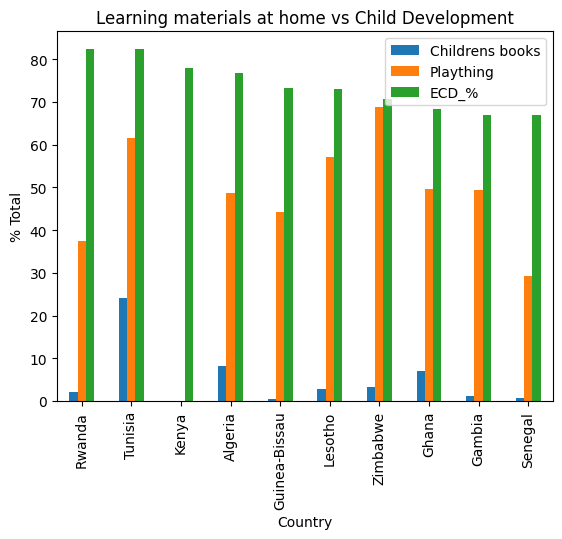

In [20]:
#### Learning materials at home
lm_df = early_df.iloc[:55,[0,11,12]]
lm_df.rename(columns={'Total.2':'Childrens books','Total.3':'Plaything'}, inplace=True)
lmm_df = lm_df.nlargest(10, 'Childrens books')
lmm_df.set_index('Country').plot(kind='bar', xlabel= 'Country', ylabel= '%_total', title= 'Children with Learning materials at home');

hhlm= lm_df.merge(cdt_df, how= 'inner', on= "Country")
hhlm = hhlm.rename(columns={'Total.5':'ECD_%'})
hhlm= hhlm.drop(columns={"Poorest 20%.3","Richest 20%.3"})
highlm= hhlm.nlargest(10, 'ECD_%')
highlm.set_index('Country').plot(kind= 'bar', xlabel= 'Country', ylabel= '% Total', title= 'Learning materials at home vs Child Development');


##### 	Access to children’s books is low in nearly all countries.
##### Playthings are more accessible than books but still show large variation.
##### Tunisia stands out with the highest access to children’s books.
##### Most other countries, such as Guinea-Bissau, Rwanda, Lesotho, Senegal, and Gambia, have very low access to books.
##### Morocco and Djibouti show lesser disparity in access to playthings and books
	
##### There appears to be no direct correlation between access to books and ECD_%. This means that other factors (like parental care, nutrition, or preschool access) might be influencing developmental outcomes more.


#### This chart shows that while many children have access to toys, far fewer have access to books, which are essential for developing literacy and academic skills. Addressing this imbalance could play a vital role in improving early childhood education outcomes.

##  Child Supervision

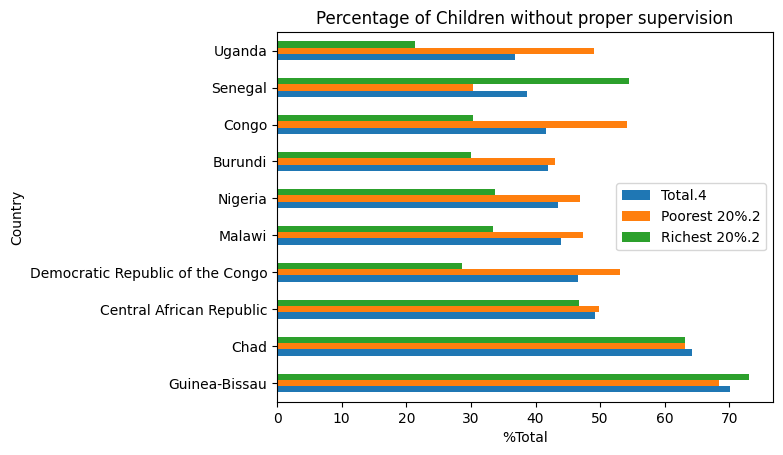

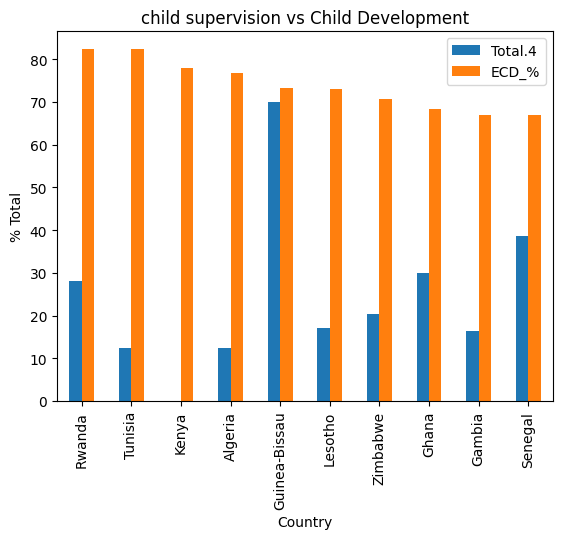

In [ ]:
### Children with inadequate supervision
cis_df = early_df.iloc[:55,[0,13,16,17]]
ciss_df = cis_df.nlargest(10,'Total.4')
ciss_df.set_index('Country').plot(kind= 'barh', ylabel= 'Country', xlabel= '%Total', title= 'Percentage of Children without proper supervision');

hhcis= cis_df.merge(cdt_df, how= 'inner', on= "Country")
hhcis = hhcis.rename(columns={'Total.5':'ECD_%'})
hhcis= hhcis.drop(columns={"Poorest 20%.2","Richest 20%.2","Poorest 20%.3","Richest 20%.3"})
highcis= hhcis.nlargest(10, 'ECD_%')
highcis.set_index('Country').plot(kind= 'bar', xlabel= 'Country', ylabel= '% Total', title= 'child supervision vs Child Development');

#### In many countries, such as Chad, Central African Republic, Democratic Republic of the Congo, Malawi, Nigeria, Burundi, and Congo, the "Poorest 20%" consistently shows a higher percentage of children without proper supervision compared to the "Richest 20%". This suggests a correlation between poverty and lack of supervision.
#### Guinea-Bissau shows a high positive developmental outcome despite having a high rate of lack of supervision, this suggests that other factors might be responsible for its positive development outcomes. Guinea-Bissau has taken several steps to improve Early Childhood Development (ECD) outcomes, including establishing a Preschool Inspection Directorate in 2017 and approving a guide for minimum criteria for preschool services in 2019. The country is also partnering with organizations like UNICEF to strengthen ECD programs, including designing and implementing a new preschool curriculum and using tools like the Brief Early Childhood Quality (BEQI) to assess classroom practices and learning environments

#### The chart highlights the prevalence of inadequate child supervision in various African countries, with the poorests segments being affected mostly.

## Nutritional Diversity

In [22]:
#### % of children consuming different food groups
fgc_df = b_df.iloc[1:55,[1,14,16,18]]
fgc_df.rename(columns={'Unnamed: 1' :'Country','<=2 food groups (severe food poverty)':'severe food poverty','3−4 food groups (moderate food poverty)':'moderate food poverty','At least 5 food groups (minimum dietary diversity)':'minimum dietary diversity'}, inplace=True)

In [ ]:
for i in range(4):
      fgc_df[fgc_df.columns[i]].replace('-',0, inplace=True)
fgc_df[fgc_df.columns[i]].astype('float')
fgch_df = fgc_df.nlargest(10,'minimum dietary diversity')


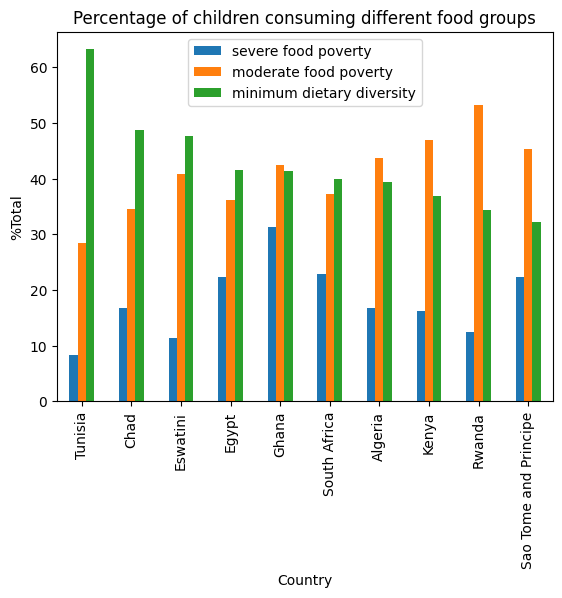

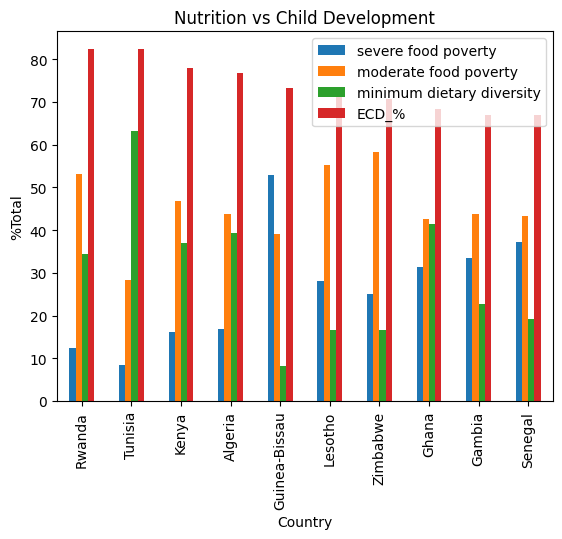

In [27]:
fgch_df.set_index('Country').plot(kind='bar', xlabel='Country', ylabel='%Total', title= 'Percentage of children consuming different food groups',)
plt.Figure(figsize=(15,5));

hhfcg= fgc_df.merge(cdt_df, how= 'inner', on= "Country")
hhfcg = hhfcg.rename(columns={'Total.5':'ECD_%'})
hhfcg= hhfcg.drop(columns={"Poorest 20%.3","Richest 20%.3"})
highfcg= hhfcg.nlargest(10, 'ECD_%')
highfcg.set_index('Country').plot(kind= 'bar', xlabel= 'Country', ylabel= '%Total', title= 'Nutrition vs Child Development');

#### This illustrates the percentage of dietary diversity in child nutrition and food security across these African nations.Lack of dietary requirements in infants is known to cause cognitive delays.
#### Tunisia shows a higher percentage of children consuming "Minimum dietary diversity" compared to "Severe food poverty" and "Moderate food poverty."

#### Rwanda, Tunisia, Kenya and Algeria which have the highest Childhood development percentage, the consumption of nutritionally deficient meals(less than two food groups) is lower when compared to other categories. In Tunisia, a larger percentage of the population consumes the standard dietary requirements for optimal development. Kenya, Rwanda and Algeria have a higher fraction of their population consuming moderate nutritional requirement(consisting of 3-4 food groups).
#### Recognizing the importance of holistic development, Kenya has integrated health and nutrition services into ECD programs. This includes providing access to healthcare and ensuring that children receive nutritious meals, particularly in schools and community centers
#### Consuming at least 3 - 4 food groups(classified as moderate food poverty) to the minimum dietary diversity contributes positively to developmental outcomes in children under the age of five.

In [ ]:
joined_df = aed_df.merge(esrc_df, how= 'inner',on= 'Country')
joined_df = joined_df.merge(lm_df,how= 'inner', on='Country')
joined_df =joined_df.merge(cis_df,how= 'inner', on='Country')
joined_df = joined_df.merge(fgc_df,how= 'inner', on='Country')
joined_df = joined_df.merge(cdt_df,how= 'inner', on='Country')


In [ ]:
data_df = joined_df.iloc[:,[0,1,4,7,8,9,12,13,14,15]]
data_df.head()
data_df = data_df.rename(columns={'Total':'Access to early education', 'Total.1':'Early Stimulation and responsive care','Total.4': 'Children with inadequate supervision', 'Total.5': 'Children developmentally on track'})

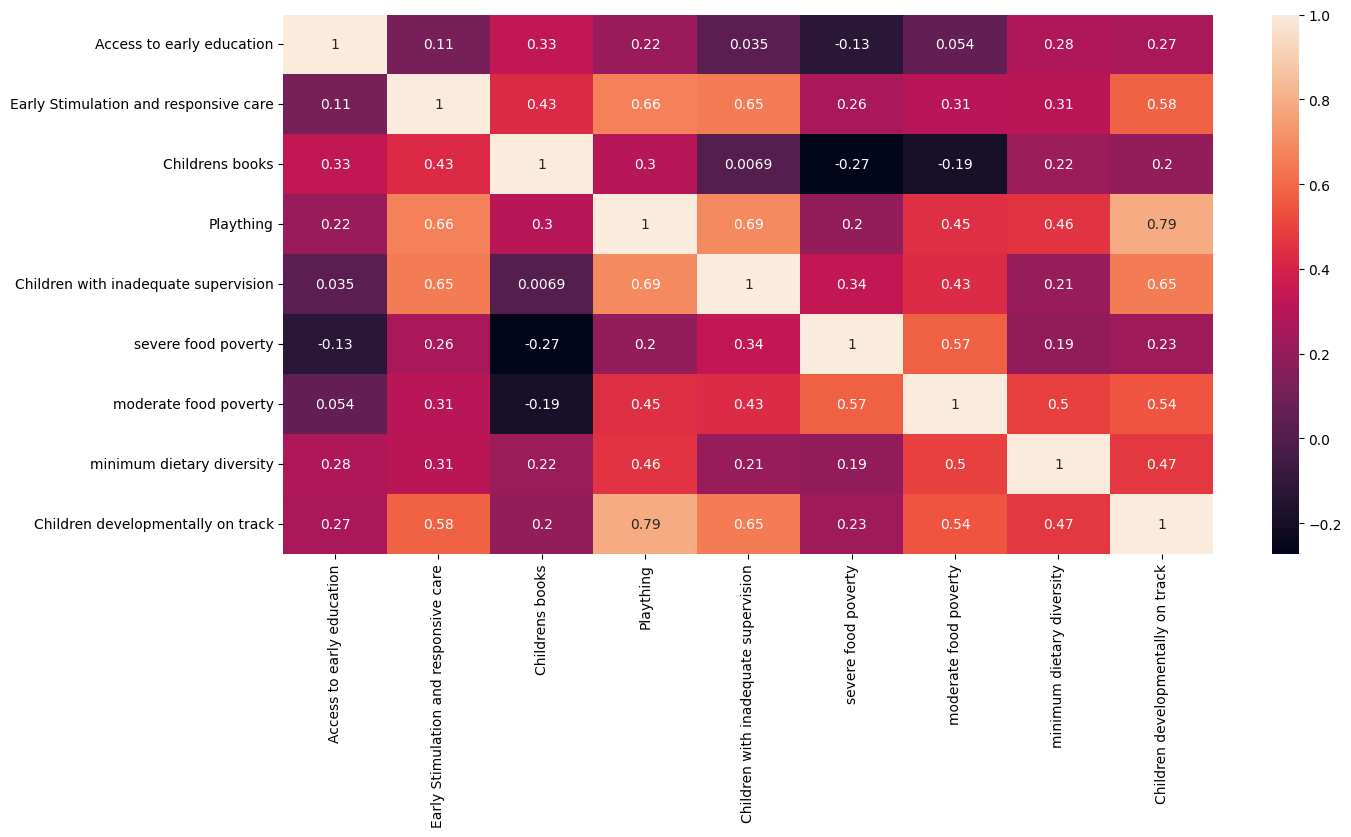

In [ ]:
Ddata_df = data_df.select_dtypes(include='float64').corr()
plt.figure(figsize=(15, 7))
sns.heatmap(Ddata_df, annot= True);

##### Children developmentally on track has strong positive correlations with:

##### Plaything(0.79): This suggests that having playthings might be beneficial for child development.
##### Early Stimulation and responsive care (0.58): This suggests that higher levels of early stimulation and responsive care are associated with children being more       developmentally on track.
##### Moderate food poverty(0.54): This suggests that consuming at least 3 - 4 food groups is just enough for child development
##### Children's books (0.2): Also a strong positive correlation, indicating that access to children's books is beneficial for development.
##### Minimum dietary diversity (0.47): A positive correlation, implying that better nutrition is linked to better development.
##### Access to early education (0.27): A weaker positive correlation compared to early stimulation, but still positive.


##### In summary, this heatmap provides quantitative evidence for the correlation of various factors influencing child development. It strongly suggests that a supportive environment, characterized by early stimulation, access to books and playthings, good nutrition, and adequate supervision, is positively correlated with children being developmentally on track.


## Recommendations

##### Expand access to affordable and quality early education programs, particularly in rural and underserved communities.
##### Implement parental training programs to promote responsive caregiving and early stimulation practices.
##### Identify countries and specific socioeconomic groups most in need of interventions to promote early childhood development. Programs aimed at supporting parents in low-income households with resources and education for early stimulation and responsive care would be highly relevant.
##### Collaborate with local NGOs and community centers to Subsidize the provision of learning materials to low-income households and also distribute educational kits and promote community playgroups.
##### Integrate nutrition and caregiving education into maternal and child health programs to encourage proper nutrition and dietary diversity in early childhood.

In [2]:
! jupyter nbconvert --to html Early_Childhood_development.ipynb

[NbConvertApp] Converting notebook Early_Childhood_development.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 10 image(s).
[NbConvertApp] Writing 837304 bytes to Early_Childhood_development.html
